=== DATASET OVERVIEW ===
Feature matrix shape (samples, features): (569, 30)
Target array shape: (569,)
Target classes: ['malignant' 'benign']
Class counts: 212 Malignant (0), 357 Benign (1)


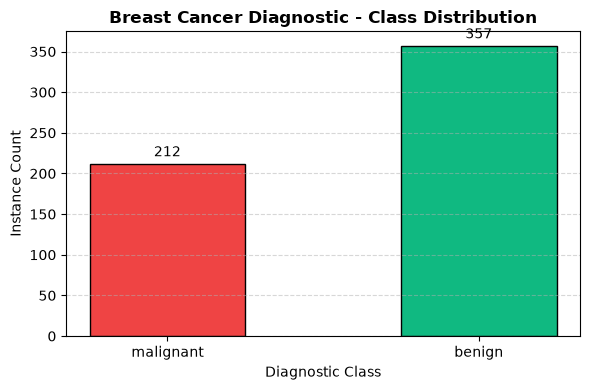

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

# Exercise 4 & 5: Load Breast Cancer Dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

print("=== DATASET OVERVIEW ===")
print("Feature matrix shape (samples, features):", X.shape)
print("Target array shape:", y.shape)
print("Target classes:", target_names)
print(f"Class counts: {np.bincount(y)[0]} Malignant (0), {np.bincount(y)[1]} Benign (1)")

# Exercise 6: Visualizing the Class Distribution
plt.figure(figsize=(6, 4))
bars = plt.bar(target_names, np.bincount(y), color=['#EF4444', '#10B981'], edgecolor='black', width=0.5)
plt.title('Breast Cancer Diagnostic - Class Distribution', fontweight='bold')
plt.xlabel('Diagnostic Class')
plt.ylabel('Instance Count')
plt.bar_label(bars, fmt='%d', padding=3)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
 
# Exercise 7: 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
 
# Exercise 8: Z-score feature standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
 
# Exercise 9: Fit Logistic Regression Classifier
classifier = LogisticRegression(random_state=0)
classifier.fit(X_train_scaled, y_train)
 
# Exercise 10: Generate test predictions
y_pred = classifier.predict(X_test_scaled)
 
print("Test predictions generated successfully!")
print("Sample predicted labels (first 10):", y_pred[:10])
print("Actual ground truth labels (first 10):", y_test[:10])


Test predictions generated successfully!
Sample predicted labels (first 10): [1 0 0 1 1 0 0 0 1 1]
Actual ground truth labels (first 10): [1 0 0 1 1 0 0 0 1 1]


Model Test Accuracy: 97.37%

Classification Report:
               precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Confusion Matrix:
 [[41  2]
 [ 1 70]]


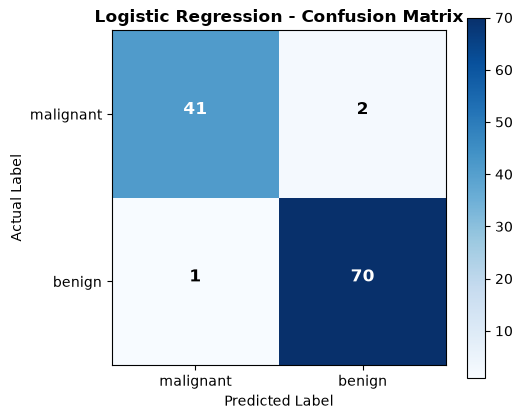

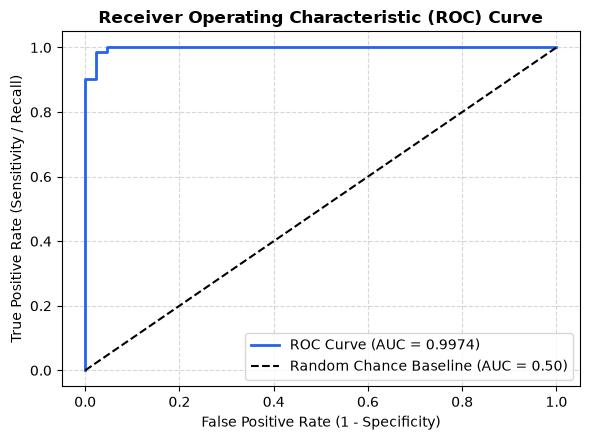

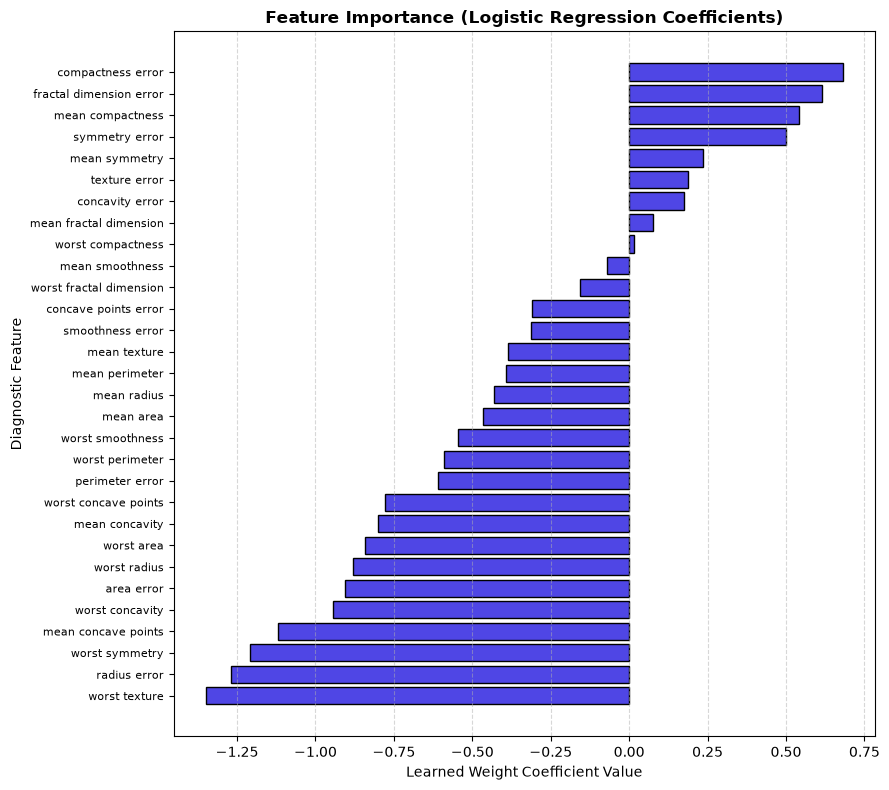

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
 
# Exercise 11: Statistical Performance Evaluation
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(f"Model Test Accuracy: {acc * 100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=target_names))
print("Confusion Matrix:\n", cm)
 
# Exercise 12: Visualizing the Confusion Matrix (2D Heatmap)
plt.figure(figsize=(5.5, 4.5))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.title('Logistic Regression - Confusion Matrix', fontweight='bold')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, target_names)
plt.yticks(tick_marks, target_names)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
 
for i in range(2):
    for j in range(2):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black",
                 fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
 
# Exercise 13: Receiver Operating Characteristic (ROC) Curve
y_pred_proba = classifier.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)
 
plt.figure(figsize=(6, 4.5))
plt.plot(fpr, tpr, color='#2563EB', linewidth=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance Baseline (AUC = 0.50)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
 
# Exercise 14: Visualizing Feature Importance (Horizontal Bar Chart)
coefficients = classifier.coef_[0]
sorted_indices = np.argsort(coefficients)
 
plt.figure(figsize=(9, 8))
plt.barh(range(len(coefficients)), coefficients[sorted_indices], color='#4F46E5', edgecolor='black')
plt.yticks(range(len(coefficients)), feature_names[sorted_indices], fontsize=8)
plt.title('Feature Importance (Logistic Regression Coefficients)', fontweight='bold')
plt.xlabel('Learned Weight Coefficient Value')
plt.ylabel('Diagnostic Feature')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [10]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
 
models = {
    "Logistic Regression": LogisticRegression(random_state=0),
    "Support Vector Machine (RBF)": SVC(probability=True, random_state=0),
    "Decision Tree": DecisionTreeClassifier(random_state=0),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=0)
}
 
benchmark_results = []
 
for name, clf in models.items():
    if "Tree" in name or "Forest" in name:
        clf.fit(X_train, y_train)
        preds = clf.predict(X_test)
        proba = clf.predict_proba(X_test)[:, 1]
    else:
        clf.fit(X_train_scaled, y_train)
        preds = clf.predict(X_test_scaled)
        proba = clf.predict_proba(X_test_scaled)[:, 1]
 
    benchmark_results.append({
        "Model Classifier": name,
        "Accuracy (%)": round(accuracy_score(y_test, preds) * 100, 2),
        "ROC-AUC": round(roc_auc_score(y_test, proba), 4),
        "Misclassifications": int((preds != y_test).sum())
    })
 
comparison_df = pd.DataFrame(benchmark_results)
print("=== CLASSIFIER BENCHMARK COMPARISON ===")
display(comparison_df)


c:\Users\POWERSPEC\Desktop\AI Project\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


=== CLASSIFIER BENCHMARK COMPARISON ===


,Model Classifier,Accuracy (%),ROC-AUC,Misclassifications
0,Logistic Regression,97.37,0.9974,3
1,Support Vector Machine (RBF),98.25,0.9974,2
2,Decision Tree,93.86,0.9369,7
3,Random Forest,96.49,0.9961,4


In [11]:
from sklearn.datasets import load_iris, load_wine
 
# Exercise 16: Pipeline Replication on Iris Dataset
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
 
X_i_train, X_i_test, y_i_train, y_i_test = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42
)
scaler_iris = StandardScaler()
X_i_train_s = scaler_iris.fit_transform(X_i_train)
X_i_test_s = scaler_iris.transform(X_i_test)
 
clf_iris = LogisticRegression(random_state=0).fit(X_i_train_s, y_i_train)
iris_acc = accuracy_score(y_i_test, clf_iris.predict(X_i_test_s))
 
print("=== EXERCISE 16: IRIS DATASET PIPELINE ===")
print(f"Iris Classes: {iris.target_names.tolist()}")
print(f"Iris Test Accuracy: {iris_acc * 100:.2f}%\n")
 
# Exercise 17: Secondary External Benchmark (Wine Recognition Dataset)
wine = load_wine()
X_wine, y_wine = wine.data, wine.target
 
X_w_train, X_w_test, y_w_train, y_w_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42
)
scaler_wine = StandardScaler()
X_w_train_s = scaler_wine.fit_transform(X_w_train)
X_w_test_s = scaler_wine.transform(X_w_test)
 
clf_wine = LogisticRegression(random_state=0).fit(X_w_train_s, y_w_train)
wine_acc = accuracy_score(y_w_test, clf_wine.predict(X_w_test_s))
 
print("=== EXERCISE 17: WINE RECOGNITION BENCHMARK ===")
print(f"Wine Classes: {wine.target_names.tolist()}")
print(f"Wine Test Accuracy: {wine_acc * 100:.2f}%")


=== EXERCISE 16: IRIS DATASET PIPELINE ===
Iris Classes: ['setosa', 'versicolor', 'virginica']
Iris Test Accuracy: 100.00%

=== EXERCISE 17: WINE RECOGNITION BENCHMARK ===
Wine Classes: ['class_0', 'class_1', 'class_2']
Wine Test Accuracy: 100.00%
